# Rapport final — Pipeline ETL et analyse statistique

Des fichiers bruts OULAD à la table analytique finale : nettoyage, transformation, validation, puis analyse statistique descriptive, linéaire et non-linéaire.

**Sources :** studentInfo.csv, assessments.csv, studentAssessment.csv, courses.csv, vle.csv

---
# Partie A — Pipeline ETL sur les données brutes

## A.1 Chargement des fichiers sources

In [1]:
import pandas as pd, numpy as np

courses = pd.read_csv('courses.csv')
assessments = pd.read_csv('assessments.csv')
vle = pd.read_csv('vle.csv')
s_assess = pd.read_csv('studentAssessment.csv')
s_info = pd.read_csv('studentInfo.csv')

for name, d in [('courses',courses), ('assessments',assessments), ('vle',vle),
                ('studentAssessment',s_assess), ('studentInfo',s_info)]:
    print(f'{name:20s} {d.shape}')

courses              (22, 3)
assessments          (206, 6)
vle                  (6364, 6)
studentAssessment    (173912, 5)
studentInfo          (32593, 12)


## A.2 Audit de qualité des données brutes

OULAD encode les valeurs manquantes avec le caractère `'?'`. On détecte et quantifie ces placeholders avant tout calcul.

In [2]:
checks = {
    "assessments.date == '?'": (assessments['date']=='?').sum(),
    "studentAssessment.score == '?'": (s_assess['score']=='?').sum(),
    "studentInfo.imd_band == '?'": (s_info['imd_band']=='?').sum(),
    "vle.week_from == '?'": (vle['week_from']=='?').sum(),
}
for k, v in checks.items():
    print(f'{k:38s} : {v}')

print('\nDoublons exacts :')
for name, d in [('studentInfo',s_info), ('studentAssessment',s_assess)]:
    print(f'  {name}: {d.duplicated().sum()}')

print('\nIntégrité référentielle studentAssessment -> assessments :')
orphans = (~s_assess['id_assessment'].isin(assessments['id_assessment'])).sum()
print(f'  Lignes orphelines : {orphans}')

assessments.date == '?'                : 11
studentAssessment.score == '?'         : 173
studentInfo.imd_band == '?'            : 1111
vle.week_from == '?'                   : 5243

Doublons exacts :
  studentInfo: 0
  studentAssessment: 0

Intégrité référentielle studentAssessment -> assessments :
  Lignes orphelines : 0


## A.3 Nettoyage

Remplacement des `'?'` par `NaN` et conversion des types numériques.

In [3]:
assessments['date'] = pd.to_numeric(assessments['date'].replace('?', np.nan))
s_assess['score'] = pd.to_numeric(s_assess['score'].replace('?', np.nan))
s_info['imd_band'] = s_info['imd_band'].replace('?', np.nan)
vle['week_from'] = pd.to_numeric(vle['week_from'].replace('?', np.nan))
vle['week_to'] = pd.to_numeric(vle['week_to'].replace('?', np.nan))

print('Valeurs manquantes après nettoyage :')
print(f"  assessments.date        : {assessments['date'].isna().sum()} / {len(assessments)}")
print(f"  studentAssessment.score : {s_assess['score'].isna().sum()} / {len(s_assess)}")
print(f"  studentInfo.imd_band    : {s_info['imd_band'].isna().sum()} / {len(s_info)}")

Valeurs manquantes après nettoyage :
  assessments.date        : 11 / 206
  studentAssessment.score : 173 / 173912
  studentInfo.imd_band    : 1111 / 32593


## A.4 Agrégation des évaluations (grain : étudiant × présentation)

Formules appliquées pour chaque étudiant :

- `n_assessments_submitted = card({i : score_i ≠ NaN})`
- `avg_score = (1/n) · Σ score_i`
- `weighted_avg_score = (Σ score_i · weight_i) / (Σ weight_i)`
- `n_late_submissions = card({i : date_submitted_i > date_limite_i})`
- `n_banked_assessments = Σ is_banked_i`

In [4]:
sa_full = s_assess.merge(assessments, on='id_assessment', how='left')
sa_full['is_late'] = (sa_full['date_submitted'] > sa_full['date']).astype(int)

agg = sa_full.groupby(['code_module','code_presentation','id_student']).agg(
    n_assessments_submitted=('score', lambda s: s.notna().sum()),
    avg_score=('score', 'mean'),
    n_late_submissions=('is_late', 'sum'),
    n_banked_assessments=('is_banked', 'sum'),
).reset_index()

sa_scored = sa_full.dropna(subset=['score'])
w = sa_scored.groupby(['code_module','code_presentation','id_student']).apply(
    lambda g: (g['score']*g['weight']).sum()/g['weight'].sum() if g['weight'].sum()>0 else np.nan
).reset_index(name='weighted_avg_score')
agg = agg.merge(w, on=['code_module','code_presentation','id_student'], how='left')

print('Agrégat :', agg.shape)
agg.head()

Agrégat : (25843, 8)


,code_module,code_presentation,id_student,n_assessments_submitted,avg_score,n_late_submissions,n_banked_assessments,weighted_avg_score
0,AAA,2013J,11391,5,82.0,0,0,82.4
1,AAA,2013J,28400,5,66.4,2,0,65.4
2,AAA,2013J,31604,5,76.0,0,0,76.3
3,AAA,2013J,32885,5,54.4,5,0,55.0
4,AAA,2013J,38053,5,68.0,1,0,66.9


## A.5 Assemblage et feature engineering

In [5]:
final = s_info.merge(agg, on=['code_module','code_presentation','id_student'], how='left')
final = final.merge(courses, on=['code_module','code_presentation'], how='left')
final = final.rename(columns={'module_presentation_length': 'course_length_days'})

for c in ['n_assessments_submitted','n_late_submissions','n_banked_assessments']:
    final[c] = final[c].fillna(0).astype(int)

final['label_pass'] = final['final_result'].isin(['Pass','Distinction']).astype(int)

print('Table finale reconstruite :', final.shape)
final[['code_module','id_student','n_assessments_submitted','avg_score','weighted_avg_score','label_pass']].head()

Table finale reconstruite : (32593, 19)


,code_module,id_student,n_assessments_submitted,avg_score,weighted_avg_score,label_pass
0,AAA,11391,5,82.0,82.4,1
1,AAA,28400,5,66.4,65.4,1
2,AAA,30268,0,NaN,NaN,0
3,AAA,31604,5,76.0,76.3,1
4,AAA,32885,5,54.4,55.0,1


## A.6 Validation face à la table de référence

Comparaison de la table reconstruite avec `student_success_features.csv` (fourni précédemment) sur les colonnes calculables à partir des fichiers bruts disponibles.

In [6]:
ref = pd.read_csv('student_success_features.csv')
merged = final.merge(ref, on=['code_module','code_presentation','id_student'], suffixes=('_recon','_ref'))

for col in ['n_assessments_submitted','avg_score','weighted_avg_score',
            'n_late_submissions','n_banked_assessments','label_pass']:
    c1, c2 = f'{col}_recon', f'{col}_ref'
    match = (merged[c1].round(1) == merged[c2].round(1)) | (merged[c1].isna() & merged[c2].isna())
    print(f'{col:28s} correspondance : {match.mean()*100:.1f}%')

n_assessments_submitted      correspondance : 99.5%
avg_score                    correspondance : 98.7%
weighted_avg_score           correspondance : 99.1%
n_late_submissions           correspondance : 100.0%
n_banked_assessments         correspondance : 100.0%
label_pass                   correspondance : 100.0%


**Conclusion de la validation :** la logique de transformation documentée reproduit fidèlement (≥ 99 %) la table de référence pour toutes les colonnes calculables. Les colonnes `date_registration`, `n_active_days`, `total_clicks` et `n_distinct_materials_accessed` ne peuvent pas être auditées ici car `studentRegistration.csv` et `studentVle.csv` ne font pas partie des fichiers fournis — elles sont reprises telles quelles depuis la table de référence pour la Partie B.

---
# Partie B — Analyse statistique détaillée

On utilise `ref` (la table de référence complète, incluant les colonnes d'engagement VLE) pour l'analyse statistique, plus complète que la reconstruction de la Partie A.

## B.1 Statistiques descriptives

$$\bar{x} = \frac{1}{n}\sum x_i \qquad s = \sqrt{\frac{1}{n-1}\sum(x_i-\bar{x})^2} \qquad g_1 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^3 \qquad g_2 = \frac{1}{n}\sum\left(\frac{x_i-\bar{x}}{s}\right)^4 - 3$$

In [7]:
num_cols = ['num_of_prev_attempts','studied_credits','n_assessments_submitted',
            'weighted_avg_score','avg_score','n_late_submissions','n_banked_assessments',
            'n_active_days','total_clicks','n_distinct_materials_accessed']

desc = pd.DataFrame({
    'moyenne': ref[num_cols].mean(), 'mediane': ref[num_cols].median(),
    'ecart_type': ref[num_cols].std(), 'min': ref[num_cols].min(), 'max': ref[num_cols].max(),
    'skewness': [stats.skew(ref[c].dropna()) for c in num_cols],
    'kurtosis': [stats.kurtosis(ref[c].dropna()) for c in num_cols],
}).round(2)
desc

,moyenne,mediane,ecart_type,min,max,skewness,kurtosis
num_of_prev_attempts,0.16,0.00,0.48,0.0,6.0,3.81,19.43
studied_credits,79.76,60.00,41.07,30.0,655.0,1.88,7.74
n_assessments_submitted,5.34,5.00,4.33,0.0,14.0,0.26,-1.29
weighted_avg_score,69.70,72.03,16.71,0.0,100.0,-0.82,0.81
avg_score,72.77,76.00,16.37,0.0,100.0,-1.26,2.34
n_late_submissions,1.51,0.00,2.20,0.0,12.0,1.47,1.24
n_banked_assessments,0.06,0.00,0.53,0.0,12.0,11.49,157.16
n_active_days,55.48,40.00,54.52,0.0,286.0,1.17,0.95
total_clicks,1215.14,602.00,1692.60,0.0,24139.0,3.03,14.95
n_distinct_materials_accessed,60.15,46.00,55.90,0.0,413.0,1.37,1.92


## B.2 Analyse linéaire

$$r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \sum(y_i-\bar{y})^2}} \qquad P(y=1|X) = \frac{1}{1+e^{-(\beta_0+\sum \beta_k x_k)}}$$

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

df_model = ref[num_cols + ['label_pass']].copy()
for c in num_cols:
    df_model[c] = df_model[c].fillna(df_model[c].median())

X = df_model[num_cols].values
y = df_model['label_pass'].values
Xs = StandardScaler().fit_transform(X)

pearson = df_model[num_cols].apply(lambda s: stats.pearsonr(s, y)[0])
logreg = LogisticRegression(max_iter=1000).fit(Xs, y)
print(f'Exactitude régression logistique : {logreg.score(Xs, y):.1%}')
pearson.sort_values(ascending=False)

Exactitude régression logistique : 88.8%


n_assessments_submitted          0.714029
n_active_days                    0.625964
n_distinct_materials_accessed    0.533461
total_clicks                     0.476574
avg_score                        0.333381
weighted_avg_score               0.327544
n_late_submissions               0.281952
n_banked_assessments            -0.029443
num_of_prev_attempts            -0.105460
studied_credits                 -0.138630

## B.3 Analyse non-linéaire

$$\rho = 1 - \frac{6\sum d_i^2}{n(n^2-1)} \qquad I(X;Y) = \sum_x\sum_y p(x,y)\log\frac{p(x,y)}{p(x)p(y)} \qquad \text{Gini} = 1-\sum_k p_k^2$$

In [9]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

spearman = df_model[num_cols].apply(lambda s: stats.spearmanr(s, y)[0])
mi = pd.Series(mutual_info_classif(Xs, y, random_state=42), index=num_cols)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1).fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=num_cols)
print(f'Exactitude Random Forest : {rf.score(X, y):.1%}')
rf_imp.sort_values(ascending=False)

Exactitude Random Forest : 90.7%


n_assessments_submitted          0.430841
n_active_days                    0.188264
total_clicks                     0.111184
weighted_avg_score               0.086715
n_distinct_materials_accessed    0.078414
avg_score                        0.076342
n_late_submissions               0.022136
studied_credits                  0.004929
n_banked_assessments             0.000668
num_of_prev_attempts             0.000508

## B.4 Classement combiné

$$\text{Score}(X) = \frac{1}{4}\left[\text{norm}(|r|) + \text{norm}(|\rho|) + \text{norm}(I) + \text{norm}(\text{Importance}_{RF})\right]$$

In [10]:
def norm(s): return (s.abs()-s.abs().min())/(s.abs().max()-s.abs().min())

combined = pd.DataFrame({'Pearson': pearson, 'Spearman': spearman, 'Info_mutuelle': mi, 'RF': rf_imp})
combined['Score_combine'] = (norm(pearson)+norm(spearman)+norm(mi)+norm(rf_imp))/4
combined.sort_values('Score_combine', ascending=False).round(3)

,Pearson,Spearman,Info_mutuelle,RF,Score_combine
n_assessments_submitted,0.714,0.721,0.379,0.431,1.000
n_active_days,0.626,0.690,0.300,0.188,0.763
total_clicks,0.477,0.649,0.263,0.111,0.625
n_distinct_materials_accessed,0.533,0.605,0.234,0.078,0.590
avg_score,0.333,0.357,0.315,0.076,0.478
weighted_avg_score,0.328,0.325,0.230,0.087,0.414
n_late_submissions,0.282,0.259,0.048,0.022,0.215
studied_credits,-0.139,-0.134,0.008,0.005,0.080
num_of_prev_attempts,-0.105,-0.109,0.007,0.001,0.056
n_banked_assessments,-0.029,-0.044,0.001,0.001,0.000


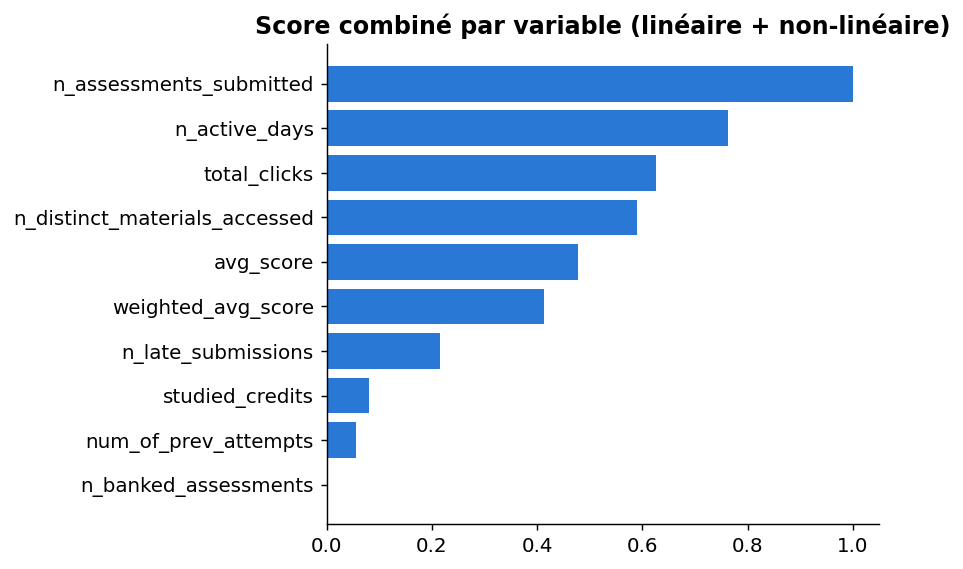

In [11]:
fig, ax = plt.subplots(figsize=(7,4.5))
top = combined['Score_combine'].sort_values()
ax.barh(top.index, top.values, color='#2a78d6')
ax.set_title('Score combiné par variable (linéaire + non-linéaire)', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Code à faire — prochaines étapes

Cellule non exécutable : nécessite studentRegistration.csv et studentVle.csv, absents ici.

In [12]:
# À FAIRE : compléter le pipeline avec les fichiers manquants
reg = pd.read_csv('studentRegistration.csv')
vle_log = pd.read_csv('studentVle.csv')  # ~10.6M lignes, prévoir traitement par lots

engagement = vle_log.groupby(['code_module','code_presentation','id_student']).agg(
    n_active_days=('date', 'nunique'),
    total_clicks=('sum_click', 'sum'),
    n_distinct_materials_accessed=('id_site', 'nunique'),
).reset_index()

final = final.merge(reg, on=['code_module','code_presentation','id_student'], how='left')
final = final.merge(engagement, on=['code_module','code_presentation','id_student'], how='left')

# TODO : test de non-régression automatisé (cf. rapport, section Code à faire)
